# A/B Experiment: Predictive KEDA vs Vanilla HPA

**Round A** = Vanilla HPA (reactive CPU-threshold, executed first)  
**Round B** = Predictive KEDA (GRU-based LPA, executed second)

Data sources:
- Locust `stats_history.csv` — per-second latency / RPS
- Prometheus `localhost:9090` — replica count, actual CPU, GRU prediction

In [1]:
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
RESULTS       = Path('../test_deployment/locusts/results')
TIMESTAMPS_F  = Path('../test_deployment/locusts/experiment_timestamps.json')
PROM          = 'http://localhost:9090/api/v1/query_range'

# ── Style (matches deep_learning_percentage_absolute_out.ipynb) ─────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLOR_A   = 'tomato'      # Vanilla HPA      — Round A
COLOR_B   = 'steelblue'   # Predictive KEDA  — Round B
COLOR_PRED = '#f4a582'    # GRU predicted CPU
LABEL_A   = 'Vanilla HPA (Round A)'
LABEL_B   = 'Predictive KEDA (Round B)'

SCENARIO_NAMES = [
    '1. Linear Ramp',
    '2. Step Function',
    '3. Sine Wave',
    '4. Multi Spike',
    '5. Random Walk',
    '6. Quiet + Burst',
]

with open(TIMESTAMPS_F) as f:
    timestamps = json.load(f)

print('Setup complete.')
print('Scenarios:', list(timestamps['round_a'].keys()))

Setup complete.
Scenarios: ['1. Linear Ramp', '2. Step Function', '3. Sine Wave', '4. Multi Spike', '5. Random Walk', '6. Quiet + Burst']


---
## 1 — Locust Data: Latency & RPS

In [2]:
def load_history(round_id: str) -> pd.DataFrame:
    df = pd.read_csv(RESULTS / f'round_{round_id}_stats_history.csv')
    df = df[df['Name'] == 'Aggregated'].copy()
    for col in ['50%', '95%', '99%', '100%']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.sort_values('Timestamp').reset_index(drop=True)
    return df

def slice_scenario(df: pd.DataFrame, name: str, round_key: str,
                   min_rps: float = 0.5) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (full_window, active_only) with 't' = seconds from scenario start."""
    ts_info = timestamps[round_key][name]
    start, end = ts_info['start_unix'], ts_info['end_unix']
    mask = (df['Timestamp'] >= start) & (df['Timestamp'] <= end)
    s = df[mask].copy()
    s['t'] = s['Timestamp'] - start
    return s, s[s['Requests/s'] > min_rps].copy()

hist_a = load_history('a')
hist_b = load_history('b')
print(f'Round A: {len(hist_a)} rows  |  Round B: {len(hist_b)} rows')

Round A: 10868 rows  |  Round B: 4406 rows


### Table 1 — Request Latency per Scenario
Reproduces `tab:latency` from the thesis (Chapter 5.5).

In [3]:
rows = []
for name in SCENARIO_NAMES:
    _, act_a = slice_scenario(hist_a, name, 'round_a')
    _, act_b = slice_scenario(hist_b, name, 'round_b')
    rows.append({
        'Scenario':    name,
        'A P50':       int(act_a['50%'].median())  if not act_a.empty else 'N/A',
        'A P95':       int(act_a['95%'].median())  if not act_a.empty else 'N/A',
        'A P99med':    int(act_a['99%'].median())  if not act_a.empty else 'N/A',
        'A P99max':    int(act_a['99%'].max())     if not act_a.empty else 'N/A',
        'B P50':       int(act_b['50%'].median())  if not act_b.empty else 'N/A',
        'B P95':       int(act_b['95%'].median())  if not act_b.empty else 'N/A',
        'B P99med':    int(act_b['99%'].median())  if not act_b.empty else 'N/A',
        'B P99max':    int(act_b['99%'].max())     if not act_b.empty else 'N/A',
    })

lat_df = pd.DataFrame(rows).set_index('Scenario')

print('=== Latency (ms): HPA (A) vs KEDA (B) ===')
print(f'{"":<22}  {"── HPA (A) ──":^32}  {"── KEDA (B) ──":^32}')
print(f'{"Scenario":<22}  {"P50":>6} {"P95":>6} {"P99med":>8} {"P99max":>8}  {"P50":>6} {"P95":>6} {"P99med":>8} {"P99max":>8}')
print('-' * 95)
for name, r in lat_df.iterrows():
    print(f'{name:<22}  {r["A P50"]:>6} {r["A P95"]:>6} {r["A P99med"]:>8} {r["A P99max"]:>8}  '
          f'{r["B P50"]:>6} {r["B P95"]:>6} {r["B P99med"]:>8} {r["B P99max"]:>8}')

lat_df

=== Latency (ms): HPA (A) vs KEDA (B) ===
                                 ── HPA (A) ──                     ── KEDA (B) ──         
Scenario                   P50    P95   P99med   P99max     P50    P95   P99med   P99max
-----------------------------------------------------------------------------------------------
1. Linear Ramp             930   2100     2600     2800     900   2000     2600     2700
2. Step Function           930   2100     2600     2700     910   2000     2600     2600
3. Sine Wave               870   2000     2500     2600     860   1900     2500     2600
4. Multi Spike             830   1900     2500     2500     830   1900     2500     2500
5. Random Walk             760   1900     2500     2500     770   1900     2400     2500
6. Quiet + Burst           660   1800     2400     2400     670   1800     2400     2400


,A P50,A P95,A P99med,A P99max,B P50,B P95,B P99med,B P99max
Scenario,,,,,,,,
1. Linear Ramp,930,2100,2600,2800,900,2000,2600,2700
2. Step Function,930,2100,2600,2700,910,2000,2600,2600
3. Sine Wave,870,2000,2500,2600,860,1900,2500,2600
4. Multi Spike,830,1900,2500,2500,830,1900,2500,2500
5. Random Walk,760,1900,2500,2500,770,1900,2400,2500
6. Quiet + Burst,660,1800,2400,2400,670,1800,2400,2400


### Figure 1 — P99 Latency per Scenario

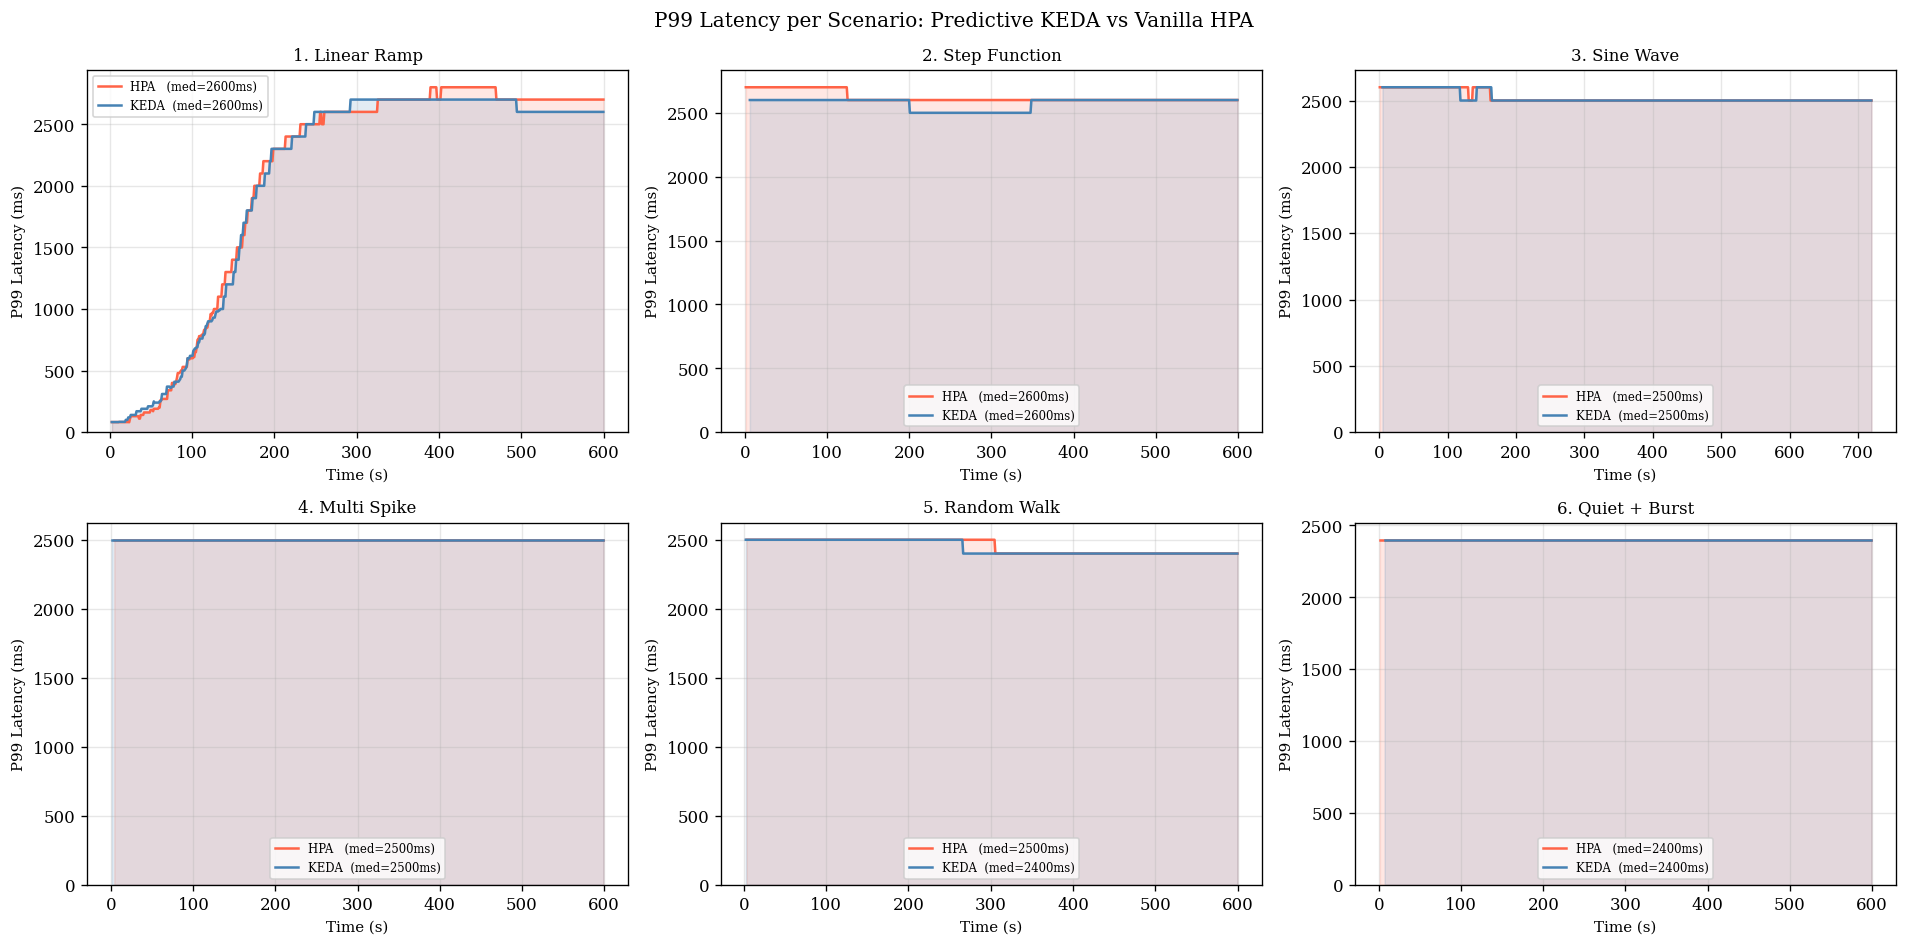

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, name in enumerate(SCENARIO_NAMES):
    ax = axes[i]
    _, act_a = slice_scenario(hist_a, name, 'round_a')
    _, act_b = slice_scenario(hist_b, name, 'round_b')

    if not act_a.empty:
        ax.fill_between(act_a['t'], act_a['99%'], alpha=0.15, color=COLOR_A)
        ax.plot(act_a['t'], act_a['99%'], color=COLOR_A, linewidth=1.5,
                label=f'HPA   (med={int(act_a["99%"].median())}ms)')
    if not act_b.empty:
        ax.fill_between(act_b['t'], act_b['99%'], alpha=0.15, color=COLOR_B)
        ax.plot(act_b['t'], act_b['99%'], color=COLOR_B, linewidth=1.5,
                label=f'KEDA  (med={int(act_b["99%"].median())}ms)')

    ax.set_title(name)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('P99 Latency (ms)')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7)

fig.suptitle('P99 Latency per Scenario: Predictive KEDA vs Vanilla HPA', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks/latency_p99_per_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 2 — RPS per Scenario

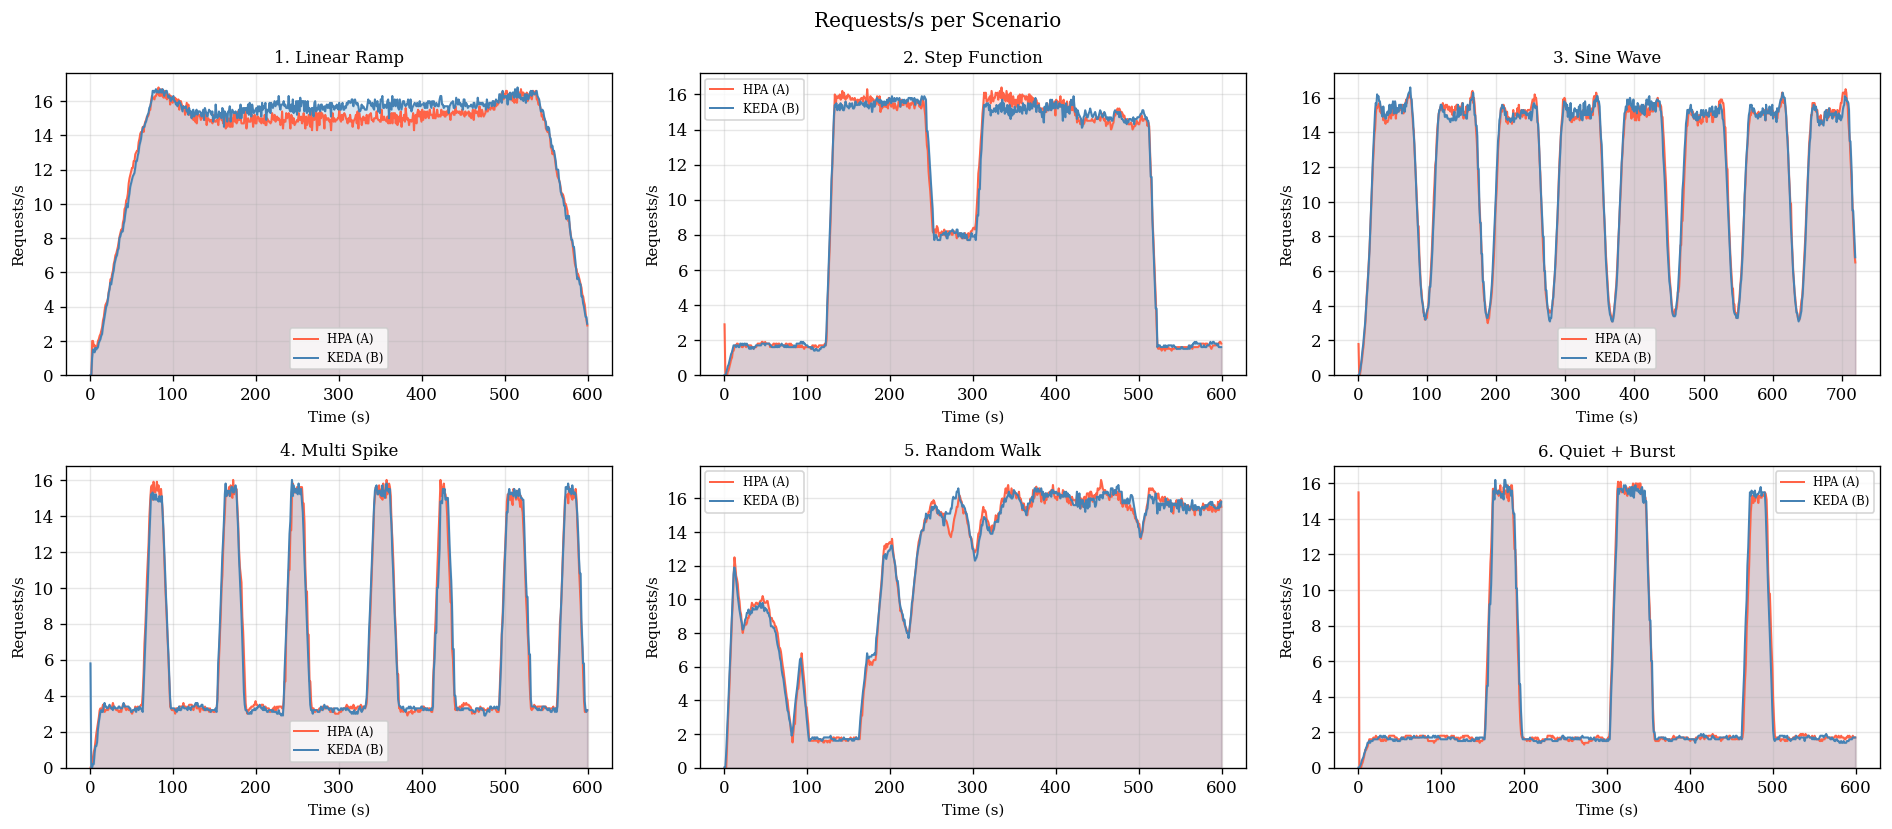

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()

for i, name in enumerate(SCENARIO_NAMES):
    ax = axes[i]
    s_a, _ = slice_scenario(hist_a, name, 'round_a', min_rps=0.0)
    s_b, _ = slice_scenario(hist_b, name, 'round_b', min_rps=0.0)

    ax.fill_between(s_a['t'], s_a['Requests/s'], alpha=0.2, color=COLOR_A)
    ax.plot(s_a['t'], s_a['Requests/s'], color=COLOR_A, linewidth=1.2, label='HPA (A)')
    ax.fill_between(s_b['t'], s_b['Requests/s'], alpha=0.2, color=COLOR_B)
    ax.plot(s_b['t'], s_b['Requests/s'], color=COLOR_B, linewidth=1.2, label='KEDA (B)')

    ax.set_title(name)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Requests/s')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7)

fig.suptitle('Requests/s per Scenario', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks/rps_per_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 3 — P99 Distribution (Box Plot + Histogram)

/tmp/ipykernel_6402/4029387272.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Vanilla\nHPA', 'Predictive\nKEDA'],
/tmp/ipykernel_6402/4029387272.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Vanilla\nHPA', 'Predictive\nKEDA'],
/tmp/ipykernel_6402/4029387272.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Vanilla\nHPA', 'Predictive\nKEDA'],


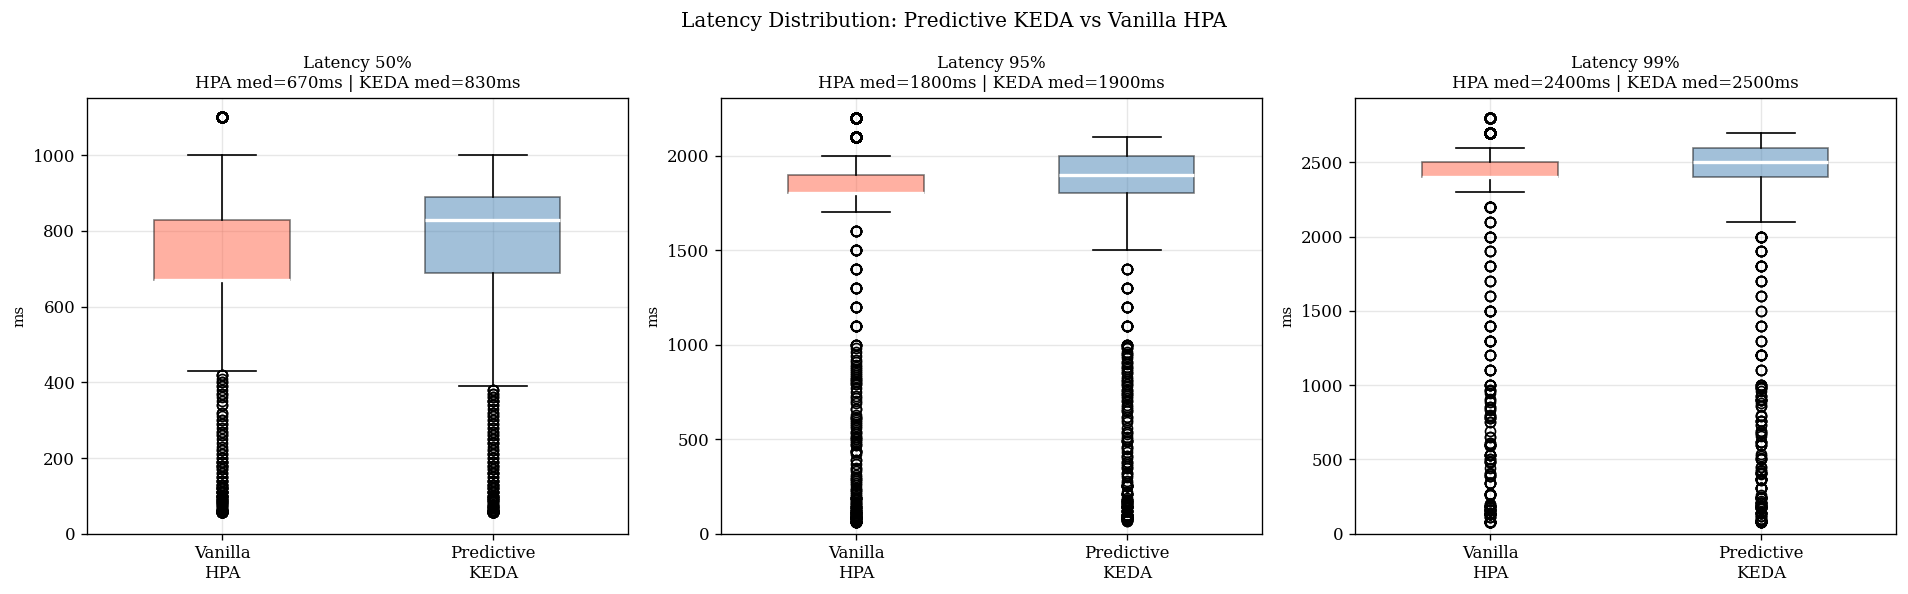


Metric                    HPA (A)     KEDA (B)       Diff
----------------------------------------------------------
  50% median                   670ms        830ms      +160ms
  95% median                  1800ms       1900ms      +100ms
  99% median                  2400ms       2500ms      +100ms

  Zero failures in both rounds: ✓


In [6]:
ra_active = hist_a[hist_a['Requests/s'] > 0.5]
rb_active = hist_b[hist_b['Requests/s'] > 0.5]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Box plots P50 / P95 / P99
for ax, pct in zip(axes[:3], ['50%', '95%', '99%']):
    data = [ra_active[pct].dropna().values, rb_active[pct].dropna().values]
    bp = ax.boxplot(data, labels=['Vanilla\nHPA', 'Predictive\nKEDA'],
                    patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor(COLOR_A)
    bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor(COLOR_B)
    bp['boxes'][1].set_alpha(0.5)
    bp['medians'][0].set_color('white')
    bp['medians'][0].set_linewidth(2)
    bp['medians'][1].set_color('white')
    bp['medians'][1].set_linewidth(2)
    a_med = ra_active[pct].median()
    b_med = rb_active[pct].median()
    ax.set_title(f'Latency {pct}\nHPA med={a_med:.0f}ms | KEDA med={b_med:.0f}ms')
    ax.set_ylabel('ms')
    ax.set_ylim(bottom=0)

fig.suptitle('Latency Distribution: Predictive KEDA vs Vanilla HPA', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks/latency_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Numerical summary
print(f'\n{"Metric":<20} {"HPA (A)":>12} {"KEDA (B)":>12} {"Diff":>10}')
print('-' * 58)
for pct in ['50%', '95%', '99%']:
    a_med = ra_active[pct].median()
    b_med = rb_active[pct].median()
    print(f'  {pct} median{"":<11} {a_med:>10.0f}ms {b_med:>10.0f}ms {b_med-a_med:>+9.0f}ms')
print(f'\n  Zero failures in both rounds: ✓')

---
## 2 — Prometheus: Replicas, CPU, Predicted CPU

In [7]:
def prom_range(query: str, start: float, end: float, step: str = '15s') -> pd.DataFrame:
    r = requests.get(PROM, params={'query': query, 'start': start, 'end': end, 'step': step},
                     timeout=10)
    result = r.json()['data']['result']
    if not result:
        return pd.DataFrame(columns=['ts', 'sec', 'value'])
    values = result[0]['values']
    df = pd.DataFrame(values, columns=['ts', 'value'])
    df['ts']    = df['ts'].astype(float)
    df['value'] = pd.to_numeric(df['value'])
    return df

def add_sec(df: pd.DataFrame, start: float) -> pd.DataFrame:
    """Add 'sec' column = seconds from scenario start."""
    if df.empty:
        return df
    df = df.copy()
    df['sec'] = df['ts'] - start
    return df

def fetch_scenario(round_key: str, scenario: str) -> dict:
    ts_info = timestamps[round_key][scenario]
    start, end = ts_info['start_unix'], ts_info['end_unix']
    replicas = add_sec(
        prom_range('kube_deployment_status_replicas_ready{deployment="cpu-service"}', start, end),
        start)
    cpu = add_sec(
        prom_range(
        'sum(rate(container_cpu_usage_seconds_total{pod=~"cpu-service-.*",container!="POD"}[30s]))'
        ' / sum(kube_pod_container_resource_limits{pod=~"cpu-service-.*",resource="cpu",container!="POD"})'
        , start, end),
        start)
    pred = add_sec(
        prom_range('gru_predicted_cpu_util', start, end),
        start)
    return {'replicas': replicas, 'cpu': cpu, 'pred': pred}

# Quick connectivity check
try:
    ts0 = timestamps['round_a']['1. Linear Ramp']
    test = prom_range('kube_deployment_status_replicas_ready{deployment="cpu-service"}',
                      ts0['start_unix'], ts0['end_unix'])
    print(f'Prometheus OK — {len(test)} points for Scenario 1 Round A')
except Exception as e:
    print(f'Prometheus connection error: {e}')

Prometheus OK — 41 points for Scenario 1 Round A


### Figure 4 — Replicas + CPU per Scenario (Thesis Figure `replica_cpu_scenarios`)

6 rows × 2 columns. Black step line = replicas (right axis). Shaded area = actual CPU (left axis). Orange dashed = GRU prediction (KEDA round only).

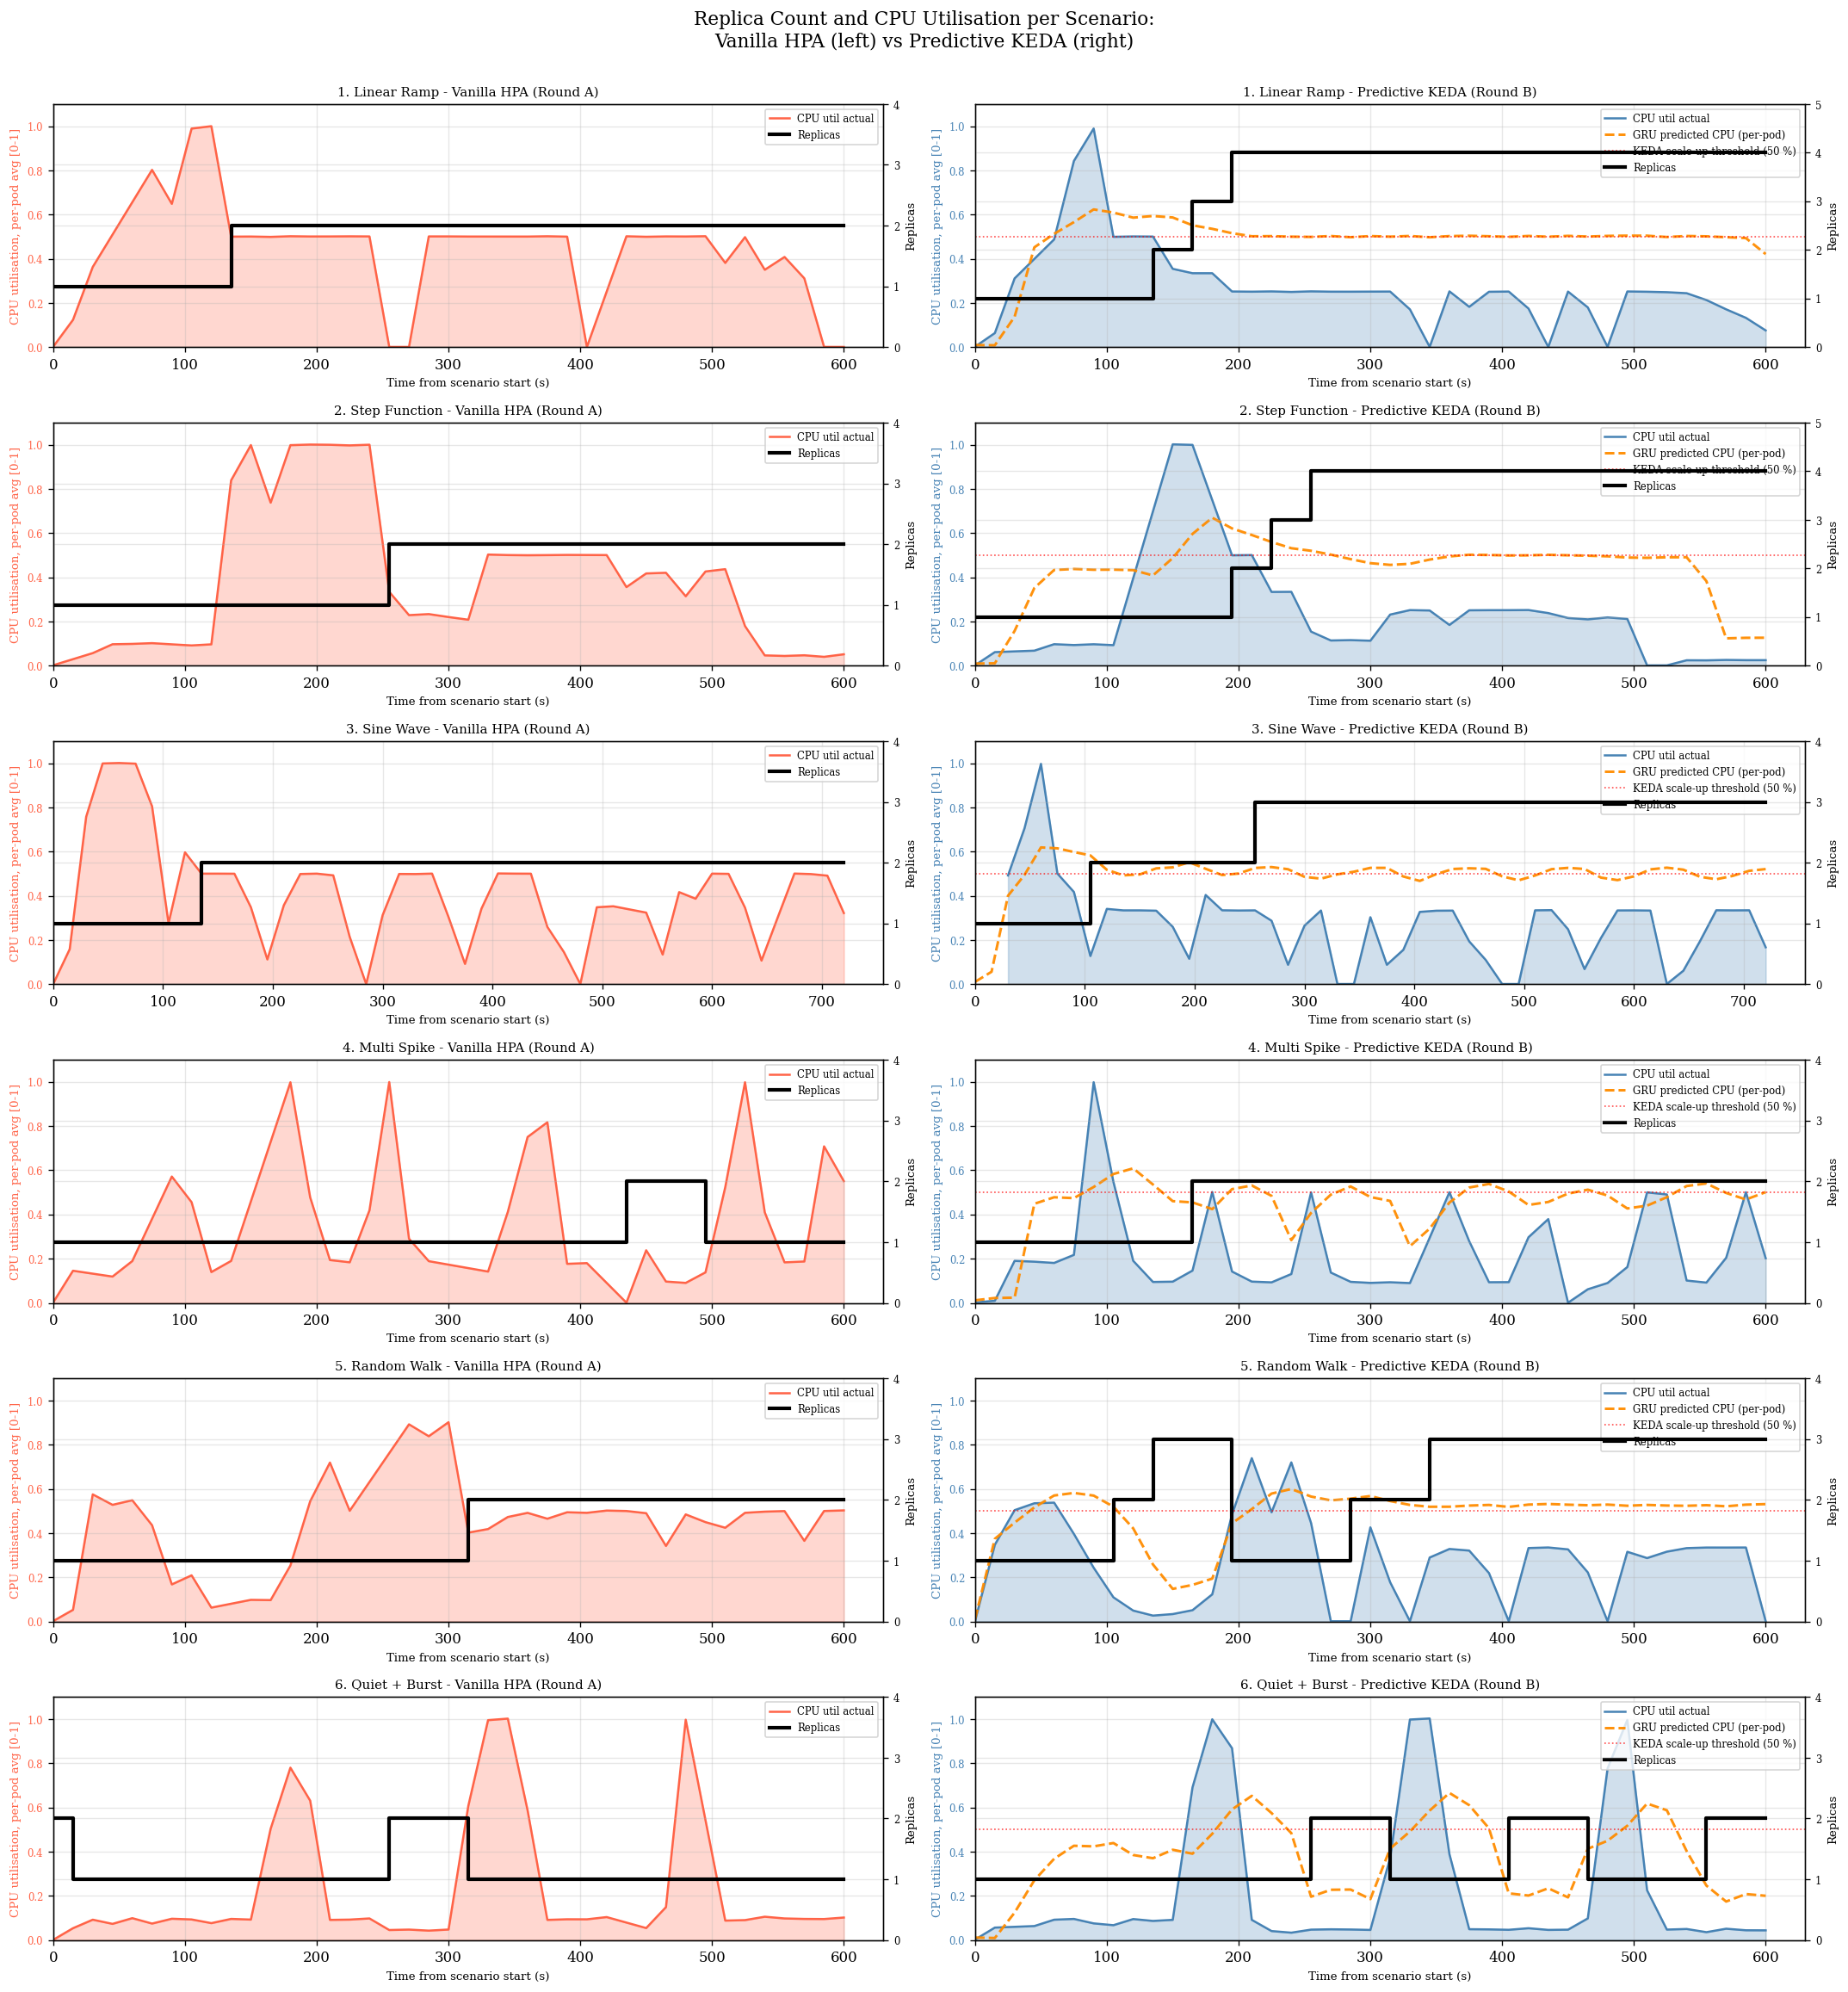

Saved: notebooks/replica_cpu_scenarios.png


In [8]:
ROUNDS = [
    ('round_a', LABEL_A, COLOR_A),
    ('round_b', LABEL_B, COLOR_B),
]

fig, axes = plt.subplots(len(SCENARIO_NAMES), 2,
                         figsize=(18, len(SCENARIO_NAMES) * 3.2))
fig.suptitle('Replica Count and CPU Utilisation per Scenario:\n'
             'Vanilla HPA (left) vs Predictive KEDA (right)',
             fontsize=13, y=1.002)

for row, scenario in enumerate(SCENARIO_NAMES):
    for col, (round_key, label, color) in enumerate(ROUNDS):
        ax = axes[row][col]
        data = fetch_scenario(round_key, scenario)

        # ── Actual CPU utilisation (left axis) ─────────────────────────
        if not data['cpu'].empty:
            ax.fill_between(data['cpu']['sec'], data['cpu']['value'],
                            alpha=0.25, color=color)
            ax.plot(data['cpu']['sec'], data['cpu']['value'],
                    color=color, linewidth=1.5, label='CPU util actual')

        # ── GRU Prediction + threshold (left axis, KEDA only) ──────────
        if round_key == 'round_b':
            if not data['pred'].empty:
                ax.plot(data['pred']['sec'], data['pred']['value'],
                        color='darkorange', linewidth=1.8, linestyle='--',
                        alpha=0.95, label='GRU predicted CPU (per-pod)')
            # 50 % threshold: when prediction crosses this, KEDA adds a replica
            x_max = data['cpu']['sec'].max() if not data['cpu'].empty else 600
            ax.axhline(0.5, color='red', linewidth=1.0, linestyle=':', alpha=0.7,
                       label='KEDA scale-up threshold (50 %)')

        ylabel = 'CPU utilisation, per-pod avg [0-1]'
        ax.set_ylabel(ylabel, color=color, fontsize=8)
        ax.tick_params(axis='y', labelcolor=color, labelsize=7)
        ax.set_ylim(0, 1.1)

        # ── Replicas (right axis) ────────────────────────────────────────
        ax2 = ax.twinx()
        if not data['replicas'].empty:
            max_r = int(data['replicas']['value'].max())
            ax2.step(data['replicas']['sec'], data['replicas']['value'],
                     color='black', linewidth=2.5, where='post', label='Replicas')
            ax2.set_ylim(0, max(max_r + 1, 4))
            ax2.yaxis.set_major_locator(mticker.MultipleLocator(1))
        ax2.set_ylabel('Replicas', fontsize=8)
        ax2.tick_params(labelsize=7)

        # ── Legend & labels ──────────────────────────────────────────────
        lines1, labs1 = ax.get_legend_handles_labels()
        lines2, labs2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labs1 + labs2, fontsize=7, loc='upper right')

        ax.set_title(scenario + ' - ' + label, fontsize=9)
        ax.set_xlabel('Time from scenario start (s)', fontsize=8)
        ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig('../notebooks/replica_cpu_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/replica_cpu_scenarios.png')


### Table — Per-Pod CPU Utilisation: Vanilla HPA vs Predictive KEDA

All values are per-pod average utilisation `[0, 1]` from Prometheus. `>50%` = fraction of time the per-pod CPU exceeded the KEDA scale-up threshold.

In [9]:
CPU_UTIL_Q = (
    'sum(rate(container_cpu_usage_seconds_total{pod=~"cpu-service-.*",container!="POD"}[30s]))'
    '/sum(kube_pod_container_resource_limits{pod=~"cpu-service-.*",resource="cpu",container!="POD"})'
)

rows = []
for name in SCENARIO_NAMES:
    vals = {}
    for round_key in ('round_a', 'round_b'):
        ts_info  = timestamps[round_key][name]
        start, end = ts_info['start_unix'], ts_info['end_unix']
        df = prom_range(CPU_UTIL_Q, start, end)
        v  = df['value'].values if not df.empty else np.array([np.nan])
        vals[round_key] = v

    a, b = vals['round_a'], vals['round_b']
    rows.append({
        'Scenario':          name,
        'A Mean':  round(np.nanmean(a), 3),
        'A Max':   round(np.nanmax(a),  3),
        'A Std':   round(np.nanstd(a),  3),
        'A >50%':  f"{(a > 0.5).mean()*100:.1f}%",
        'B Mean':  round(np.nanmean(b), 3),
        'B Max':   round(np.nanmax(b),  3),
        'B Std':   round(np.nanstd(b),  3),
        'B >50%':  f"{(b > 0.5).mean()*100:.1f}%",
        'Δ Mean':  f"{np.nanmean(b)-np.nanmean(a):+.3f}",
        'Δ Max':   f"{np.nanmax(b)-np.nanmax(a):+.3f}",
    })

cpu_df = pd.DataFrame(rows).set_index('Scenario')
print('=== Per-Pod CPU Utilisation [0-1]: Vanilla HPA (A) vs Predictive KEDA (B) ===\n')
print(f'{"Scenario":<22}  {"── Vanilla HPA (A) ──":^37}  {"── Predictive KEDA (B) ──":^37}  {"── Delta ──":^22}')
print(f'{"":22}  {"Mean":>6} {"Max":>6} {"Std":>6} {">50%":>8}  {"Mean":>6} {"Max":>6} {"Std":>6} {">50%":>8}  {"ΔMean":>10} {"ΔMax":>10}')
print('-' * 120)
for name, r in cpu_df.iterrows():
    print(f'{name:<22}  {r["A Mean"]:>6.3f} {r["A Max"]:>6.3f} {r["A Std"]:>6.3f} {r["A >50%"]:>8}  '
          f'{r["B Mean"]:>6.3f} {r["B Max"]:>6.3f} {r["B Std"]:>6.3f} {r["B >50%"]:>8}  '
          f'{r["Δ Mean"]:>10} {r["Δ Max"]:>10}')

cpu_df


=== Per-Pod CPU Utilisation [0-1]: Vanilla HPA (A) vs Predictive KEDA (B) ===

Scenario                        ── Vanilla HPA (A) ──                ── Predictive KEDA (B) ──             ── Delta ──      
                          Mean    Max    Std     >50%    Mean    Max    Std     >50%       ΔMean       ΔMax
------------------------------------------------------------------------------------------------------------------------
1. Linear Ramp           0.428  1.000  0.244    58.3%   0.270  0.989  0.194    10.0%      -0.158     -0.011
2. Step Function         0.393  1.001  0.323    37.5%   0.212  1.002  0.226     8.1%      -0.182     +0.001
3. Sine Wave             0.409  1.002  0.234    35.4%   0.273  0.998  0.182     6.4%      -0.136     -0.004
4. Multi Spike           0.358  0.999  0.286    26.5%   0.224  0.999  0.199    17.1%      -0.134     -0.001
5. Random Walk           0.440  0.902  0.208    34.2%   0.270  0.739  0.198    12.2%      -0.169     -0.163
6. Quiet + Burst         0.

,A Mean,A Max,A Std,A >50%,B Mean,B Max,B Std,B >50%,Δ Mean,Δ Max
Scenario,,,,,,,,,,
1. Linear Ramp,0.428,1.000,0.244,58.3%,0.270,0.989,0.194,10.0%,-0.158,-0.011
2. Step Function,0.393,1.001,0.323,37.5%,0.212,1.002,0.226,8.1%,-0.182,+0.001
3. Sine Wave,0.409,1.002,0.234,35.4%,0.273,0.998,0.182,6.4%,-0.136,-0.004
4. Multi Spike,0.358,0.999,0.286,26.5%,0.224,0.999,0.199,17.1%,-0.134,-0.001
5. Random Walk,0.440,0.902,0.208,34.2%,0.270,0.739,0.198,12.2%,-0.169,-0.163
6. Quiet + Burst,0.223,1.002,0.289,20.5%,0.227,1.003,0.325,17.5%,+0.004,+0.001


### Table 2 + Figure 5 — Scale-Up Lag

Scale-up lag = seconds from scenario start to the first increase in `replicas_ready` above initial value.

In [10]:
def measure_scaleup_lag(replicas_df: pd.DataFrame) -> dict:
    """Return initial replica count, max, and scale-up lag in seconds."""
    if replicas_df.empty:
        return {'init': None, 'max': None, 'lag_s': None}
    init = replicas_df['value'].iloc[0]
    peak = replicas_df['value'].max()
    scale_rows = replicas_df[replicas_df['value'] > init]
    lag = scale_rows['sec'].iloc[0] if not scale_rows.empty else None
    return {'init': int(init), 'max': int(peak), 'lag_s': round(lag) if lag is not None else None}

print(f'{"Scenario":<22}  {"HPA Init":>9}  {"HPA Max":>8}  {"HPA Lag":>10}   ||  {"KEDA Init":>8}  {"KEDA Max":>7}  {"KEDA Lag":>9}')
print('-' * 95)

lag_rows = []
for name in SCENARIO_NAMES:
    da = fetch_scenario('round_a', name)
    db = fetch_scenario('round_b', name)
    ma = measure_scaleup_lag(da['replicas'])
    mb = measure_scaleup_lag(db['replicas'])

    lag_a = f"{ma['lag_s']} s" if ma['lag_s'] is not None else 'pre-warmed'
    lag_b = f"{mb['lag_s']} s" if mb['lag_s'] is not None else '—'

    print(f'{name:<22}  {str(ma["init"]):>9}  {str(ma["max"]):>8}  {lag_a:>10}  ||  '
          f'{str(mb["init"]):>8}  {str(mb["max"]):>7}  {lag_b:>9}')
    lag_rows.append({'Scenario': name,
                     'A_init': ma['init'], 'A_max': ma['max'], 'A_lag': lag_a,
                     'B_init': mb['init'], 'B_max': mb['max'], 'B_lag': lag_b})

lag_df = pd.DataFrame(lag_rows)

Scenario                 HPA Init   HPA Max     HPA Lag   ||  KEDA Init  KEDA Max   KEDA Lag
-----------------------------------------------------------------------------------------------
1. Linear Ramp                  1         2       135 s  ||         1        4      135 s
2. Step Function                1         2       255 s  ||         1        4      195 s
3. Sine Wave                    1         2       135 s  ||         1        3      105 s
4. Multi Spike                  1         2       435 s  ||         1        2      165 s
5. Random Walk                  1         2       315 s  ||         1        3      105 s
6. Quiet + Burst                2         2  pre-warmed  ||         1        2      255 s


### Figure 5 — Replica Timeline: Scenario 1 (Linear Ramp) clean comparison

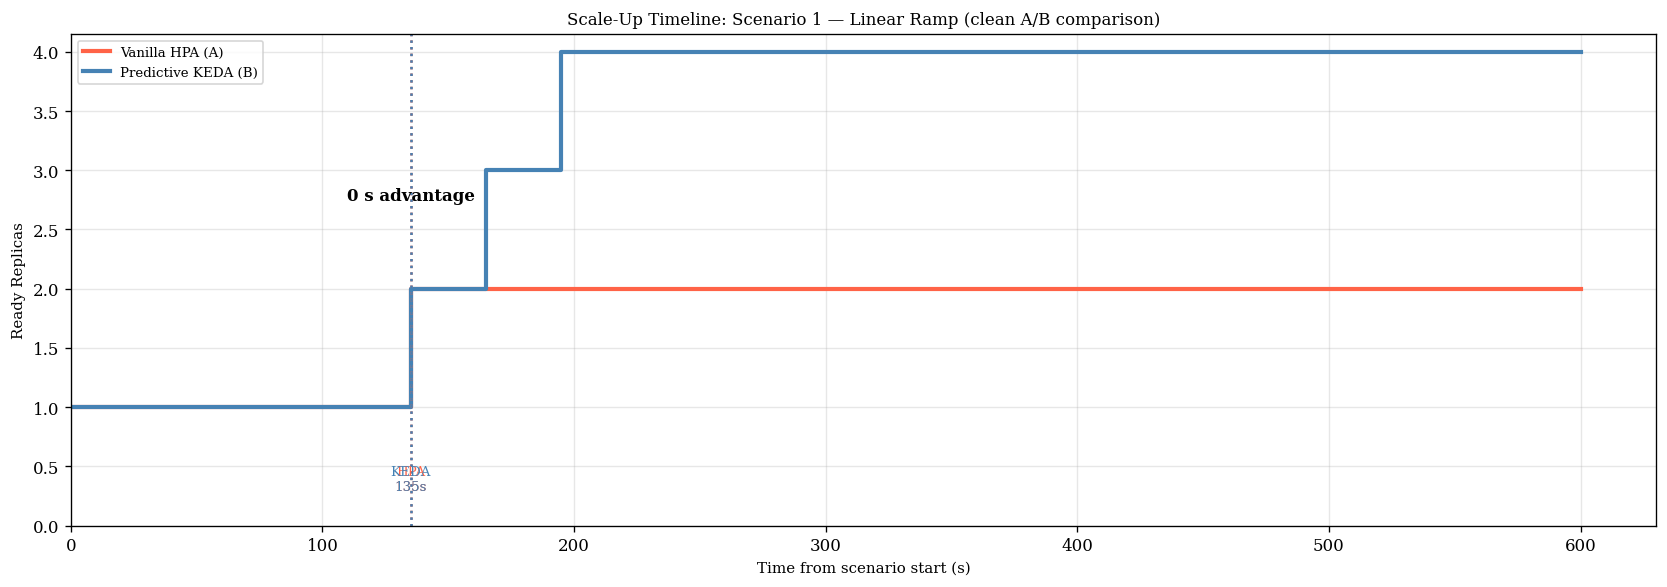

In [11]:
da1 = fetch_scenario('round_a', '1. Linear Ramp')
db1 = fetch_scenario('round_b', '1. Linear Ramp')

fig, ax = plt.subplots(figsize=(14, 5))

if not da1['replicas'].empty:
    ax.step(da1['replicas']['sec'], da1['replicas']['value'],
            where='post', color=COLOR_A, linewidth=2.5, label='Vanilla HPA (A)')
if not db1['replicas'].empty:
    ax.step(db1['replicas']['sec'], db1['replicas']['value'],
            where='post', color=COLOR_B, linewidth=2.5, label='Predictive KEDA (B)')

# Scale-up lag annotation
ma = measure_scaleup_lag(da1['replicas'])
mb = measure_scaleup_lag(db1['replicas'])
if ma['lag_s'] and mb['lag_s']:
    ax.axvline(ma['lag_s'], ls=':', color=COLOR_A, lw=1.5)
    ax.axvline(mb['lag_s'], ls=':', color=COLOR_B, lw=1.5)
    mid = (ma['lag_s'] + mb['lag_s']) / 2
    diff = mb['lag_s'] - ma['lag_s']
    ax.annotate('', xy=(mb['lag_s'], 2.5), xytext=(ma['lag_s'], 2.5),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text(mid, 2.75, f'{diff} s advantage', ha='center', fontsize=10, fontweight='bold')
    ax.text(ma['lag_s'], 0.3, f'HPA\n{ma["lag_s"]}s',  ha='center', fontsize=8, color=COLOR_A)
    ax.text(mb['lag_s'], 0.3, f'KEDA\n{mb["lag_s"]}s', ha='center', fontsize=8, color=COLOR_B)

ax.set_xlabel('Time from scenario start (s)')
ax.set_ylabel('Ready Replicas')
ax.set_title('Scale-Up Timeline: Scenario 1 — Linear Ramp (clean A/B comparison)')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/scaleup_lag_scenario1.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 6 — Scale-Up Timeline: All 6 Scenarios

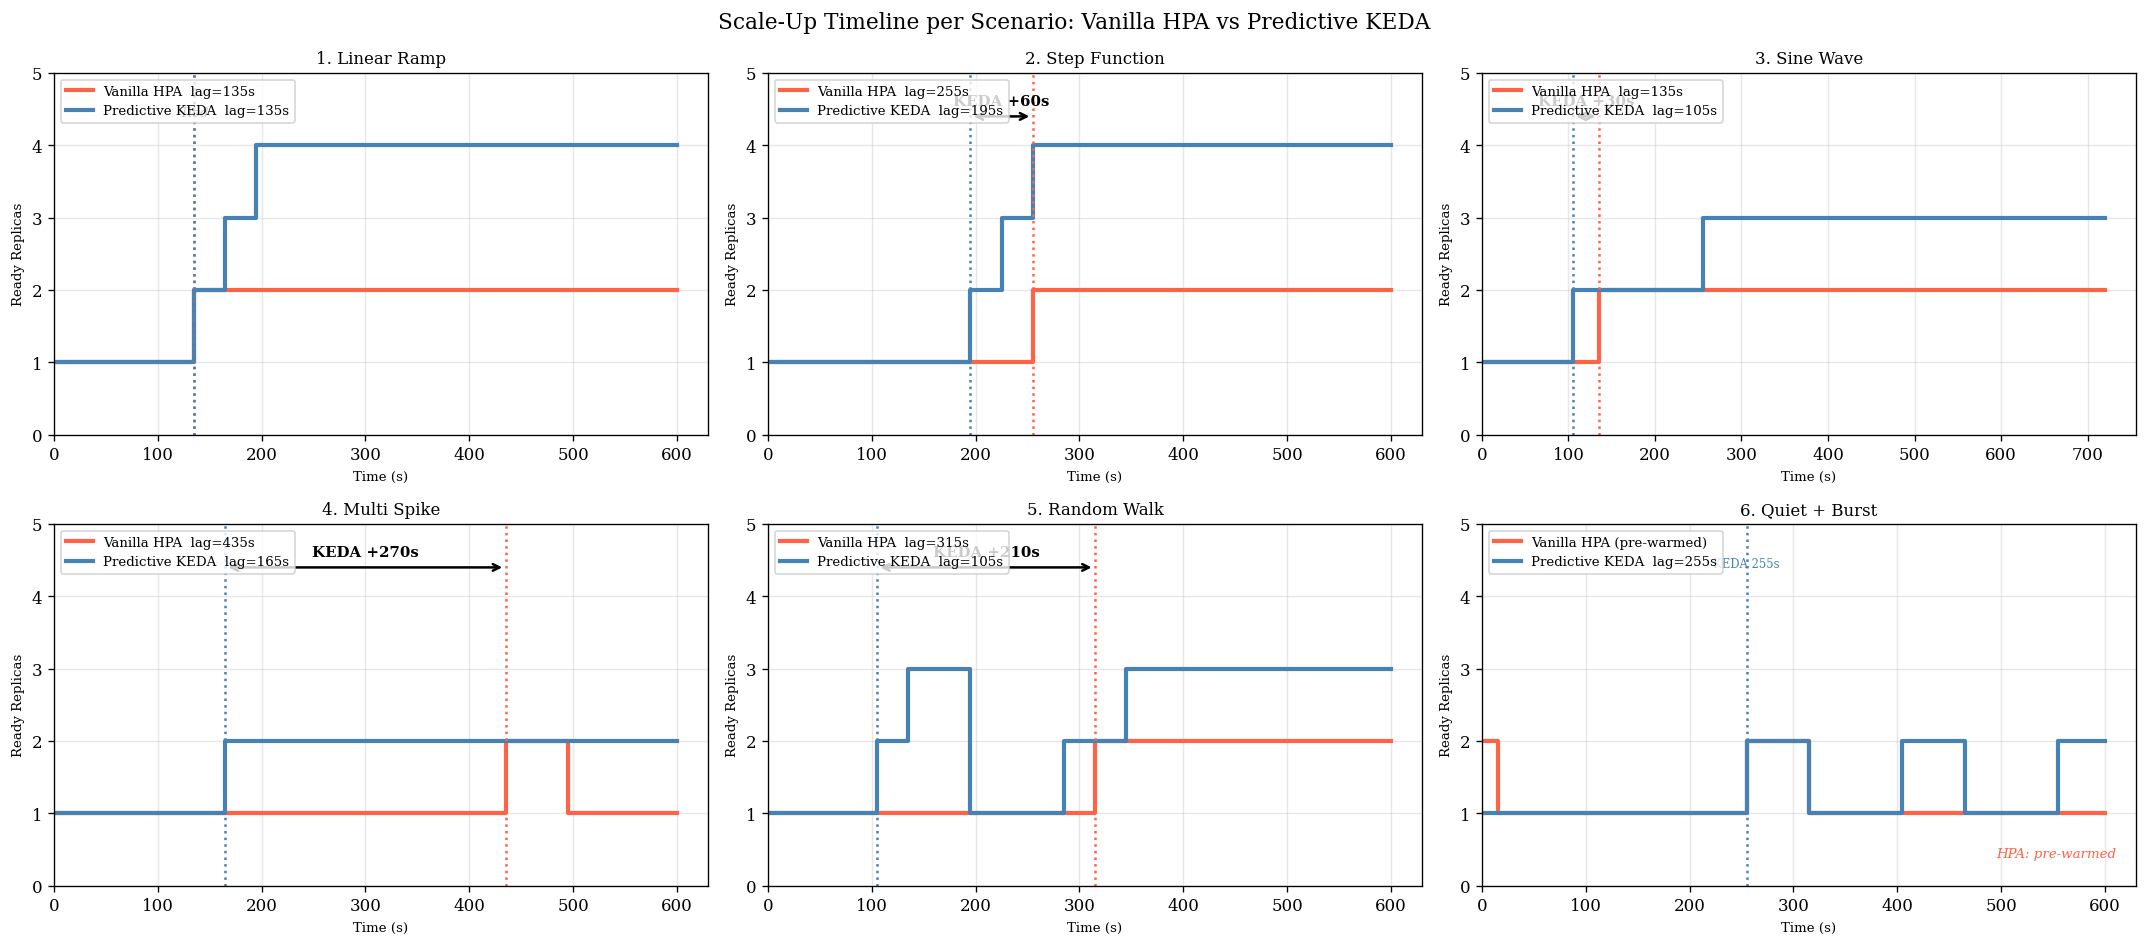

Saved: notebooks/scaleup_lag_all_scenarios.png


In [12]:
# Визначаємо спільний ylim для всіх субплотів
global_ymax = 0
for name in SCENARIO_NAMES:
    da = fetch_scenario('round_a', name)
    db = fetch_scenario('round_b', name)
    for d in [da, db]:
        if not d['replicas'].empty:
            global_ymax = max(global_ymax, d['replicas']['value'].max())
global_ymax = global_ymax + 1  # відступ зверху

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, name in enumerate(SCENARIO_NAMES):
    ax = axes[i]
    da = fetch_scenario('round_a', name)
    db = fetch_scenario('round_b', name)
    ma = measure_scaleup_lag(da['replicas'])
    mb = measure_scaleup_lag(db['replicas'])

    lbl_a = ('Vanilla HPA  lag=' + str(ma['lag_s']) + 's') if ma['lag_s'] else 'Vanilla HPA (pre-warmed)'
    lbl_b = ('Predictive KEDA  lag=' + str(mb['lag_s']) + 's') if mb['lag_s'] else 'Predictive KEDA (pre-warmed)'

    if not da['replicas'].empty:
        ax.step(da['replicas']['sec'], da['replicas']['value'],
                where='post', color=COLOR_A, linewidth=2.5, label=lbl_a)
    if not db['replicas'].empty:
        ax.step(db['replicas']['sec'], db['replicas']['value'],
                where='post', color=COLOR_B, linewidth=2.5, label=lbl_b)

    y_arr = global_ymax - 0.6

    if ma['lag_s'] and mb['lag_s']:
        diff = ma['lag_s'] - mb['lag_s']
        if diff == 0:
            # Tied — просто вертикальні лінії без стрілки
            ax.axvline(ma['lag_s'], ls=':', color=COLOR_A, lw=1.5)
            ax.axvline(mb['lag_s'], ls=':', color=COLOR_B, lw=1.5)
            ax.text(ma['lag_s'], y_arr, 'Tied', ha='center', fontsize=8, fontstyle='italic')
        else:
            ax.axvline(ma['lag_s'], ls=':', color=COLOR_A, lw=1.5)
            ax.axvline(mb['lag_s'], ls=':', color=COLOR_B, lw=1.5)
            mid = (ma['lag_s'] + mb['lag_s']) / 2
            ax.annotate('', xy=(min(ma['lag_s'], mb['lag_s']), y_arr),
                        xytext=(max(ma['lag_s'], mb['lag_s']), y_arr),
                        arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
            adv = ('KEDA +' + str(diff) + 's') if diff > 0 else ('HPA +' + str(-diff) + 's')
            ax.text(mid, y_arr + 0.15, adv, ha='center', fontsize=9, fontweight='bold')
    elif ma['lag_s'] and not mb['lag_s']:
        ax.axvline(ma['lag_s'], ls=':', color=COLOR_A, lw=1.5)
        ax.text(ma['lag_s'], y_arr, 'HPA ' + str(ma['lag_s']) + 's',
                ha='center', fontsize=7, color=COLOR_A)
        ax.text(0.97, 0.08, 'KEDA: pre-warmed', transform=ax.transAxes,
                ha='right', fontsize=8, color=COLOR_B, style='italic')
    elif mb['lag_s'] and not ma['lag_s']:
        ax.axvline(mb['lag_s'], ls=':', color=COLOR_B, lw=1.5)
        ax.text(mb['lag_s'], y_arr, 'KEDA ' + str(mb['lag_s']) + 's',
                ha='center', fontsize=7, color=COLOR_B)
        ax.text(0.97, 0.08, 'HPA: pre-warmed', transform=ax.transAxes,
                ha='right', fontsize=8, color=COLOR_A, style='italic')

    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=8)
    ax.set_ylabel('Ready Replicas', fontsize=8)
    ax.set_xlim(left=0)
    ax.set_ylim(0, global_ymax)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Scale-Up Timeline per Scenario: Vanilla HPA vs Predictive KEDA', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/scaleup_lag_all_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/scaleup_lag_all_scenarios.png')


### Table 3 + Figure 6 — Over-Provisioning

Mean and peak replicas per scenario. Over-provisioning ratio = KEDA mean / HPA mean.

In [13]:
def mean_replicas(replicas_df: pd.DataFrame) -> float | None:
    if replicas_df.empty:
        return None
    # Weighted mean by time step
    df = replicas_df.copy().sort_values('sec').reset_index(drop=True)
    if len(df) < 2:
        return float(df['value'].iloc[0])
    dt = df['sec'].diff().fillna(0)
    return float(np.average(df['value'], weights=dt.clip(lower=0) + 1e-9))

op_rows = []
for name in SCENARIO_NAMES:
    da = fetch_scenario('round_a', name)
    db = fetch_scenario('round_b', name)
    a_mean = mean_replicas(da['replicas'])
    b_mean = mean_replicas(db['replicas'])
    a_max  = int(da['replicas']['value'].max()) if not da['replicas'].empty else None
    b_max  = int(db['replicas']['value'].max()) if not db['replicas'].empty else None
    ratio  = a_mean / b_mean if a_mean and b_mean else None
    op_rows.append({'Scenario': name,
                    'A_mean': a_mean, 'A_max': a_max,
                    'B_mean': b_mean, 'B_max': b_max,
                    'Ratio': ratio})

op_df = pd.DataFrame(op_rows)

print(f'{"Scenario":<22}  {"HPA Mean":>9}   {"HPA Max":>8}  {"KEDA Mean":>9}  {"KEDA Max":>7}  {"Ratio":>7}')
print('-' * 78)
for _, r in op_df.iterrows():
    ratio_str = f"{r['Ratio']:.1f}×" if r['Ratio'] else '—'
    print(f'{r["Scenario"]:<22}  {r["A_mean"]:>9.1f}  {str(r["A_max"]):>8}  '
          f'{r["B_mean"]:>9.1f}  {str(r["B_max"]):>7}  {ratio_str:>7}')
print('-' * 78)
a_ov = op_df['A_mean'].mean()
b_ov = op_df['B_mean'].mean()
print(f'{"Overall":<22}  {a_ov:>9.1f}  {"—":>8}  {b_ov:>9.1f}  {"—":>7}  {a_ov/b_ov:>6.1f}×')

Scenario                 HPA Mean    HPA Max  KEDA Mean  KEDA Max    Ratio
------------------------------------------------------------------------------
1. Linear Ramp                1.8         2        3.2        4     0.6×
2. Step Function              1.6         2        2.9        4     0.5×
3. Sine Wave                  1.8         2        2.5        3     0.7×
4. Multi Spike                1.1         2        1.7        2     0.6×
5. Random Walk                1.5         2        2.2        3     0.7×
6. Quiet + Burst              1.1         2        1.3        2     0.8×
------------------------------------------------------------------------------
Overall                       1.5         —        2.3        —     0.6×


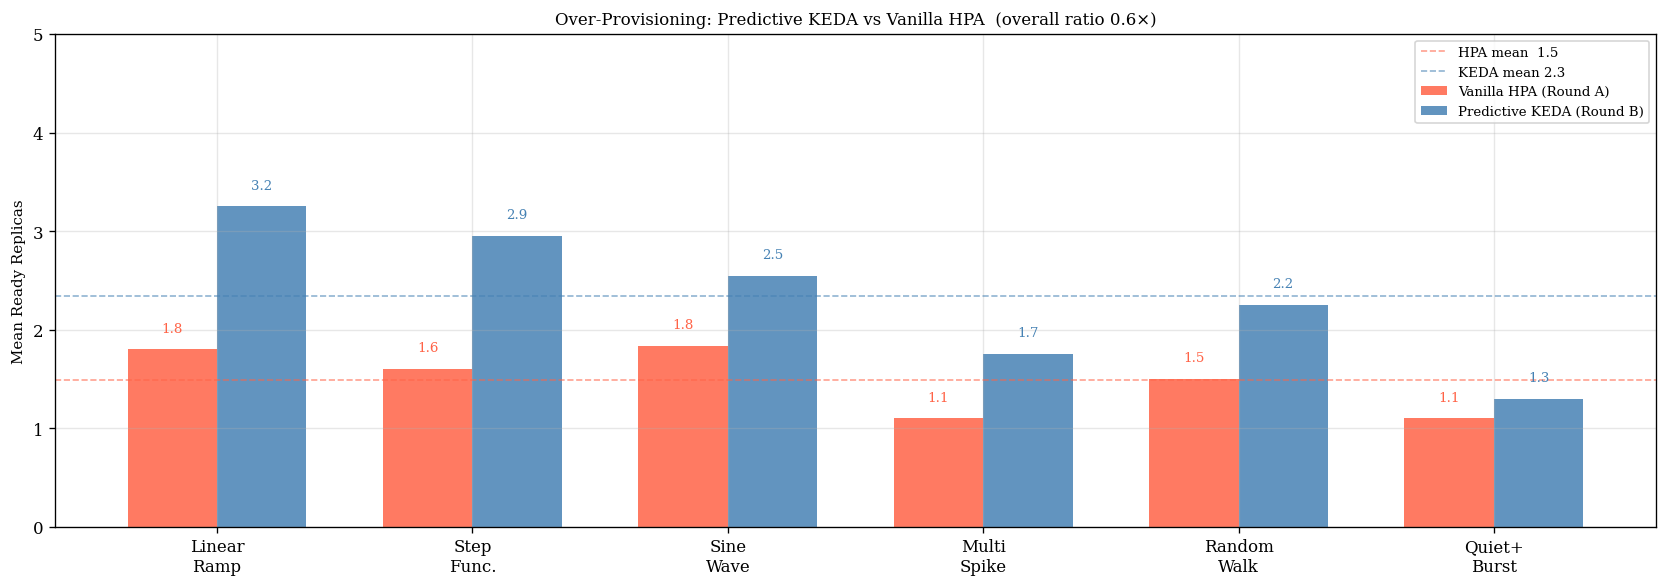

In [14]:
short = ['Linear\nRamp', 'Step\nFunc.', 'Sine\nWave', 'Multi\nSpike', 'Random\nWalk', 'Quiet+\nBurst']
x = np.arange(len(SCENARIO_NAMES))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars_a = ax.bar(x - w/2, op_df['A_mean'], w, label=LABEL_A, color=COLOR_A, alpha=0.85)
bars_b = ax.bar(x + w/2, op_df['B_mean'], w, label=LABEL_B, color=COLOR_B, alpha=0.85)

for bar, color in [(bars_a, COLOR_A), (bars_b, COLOR_B)]:
    for b in bar:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.15,
                f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=8, color=color)

ax.axhline(a_ov, ls='--', lw=1, color=COLOR_A, alpha=0.6, label=f'HPA mean  {a_ov:.1f}')
ax.axhline(b_ov, ls='--', lw=1, color=COLOR_B, alpha=0.6, label=f'KEDA mean {b_ov:.1f}')

ax.set_xticks(x)
ax.set_xticklabels(short)
ax.set_ylabel('Mean Ready Replicas')
ax.set_title(f'Over-Provisioning: Predictive KEDA vs Vanilla HPA  '
             f'(overall ratio {a_ov/b_ov:.1f}×)')
ax.legend()
ax.set_ylim(0, max(op_df['A_max'].max(), op_df['B_max'].max()) * 1.25)
plt.tight_layout()
plt.savefig('../notebooks/overprovisioning_bar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3 — Focus: Multi Spike & Quiet+Burst (adversarial scenarios)

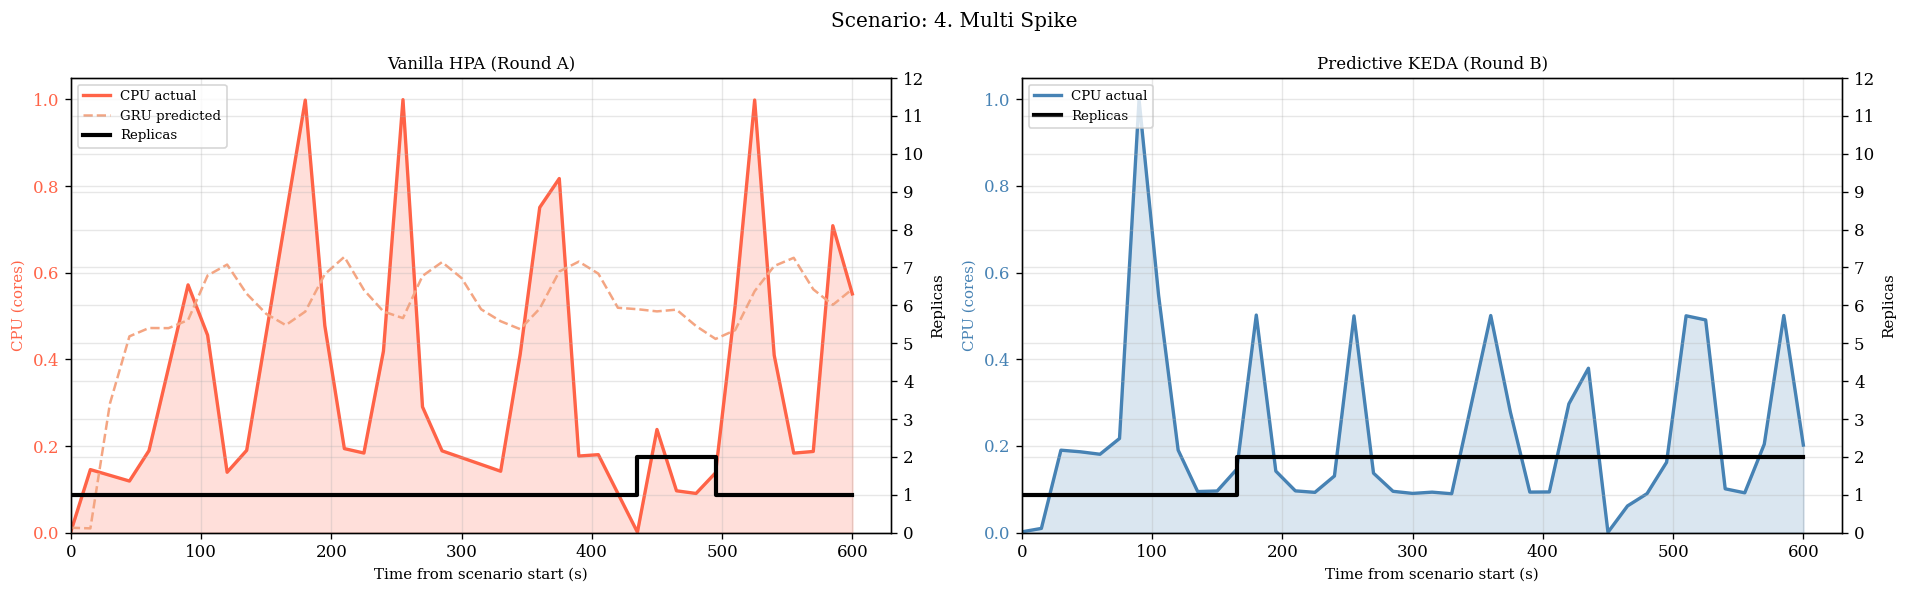

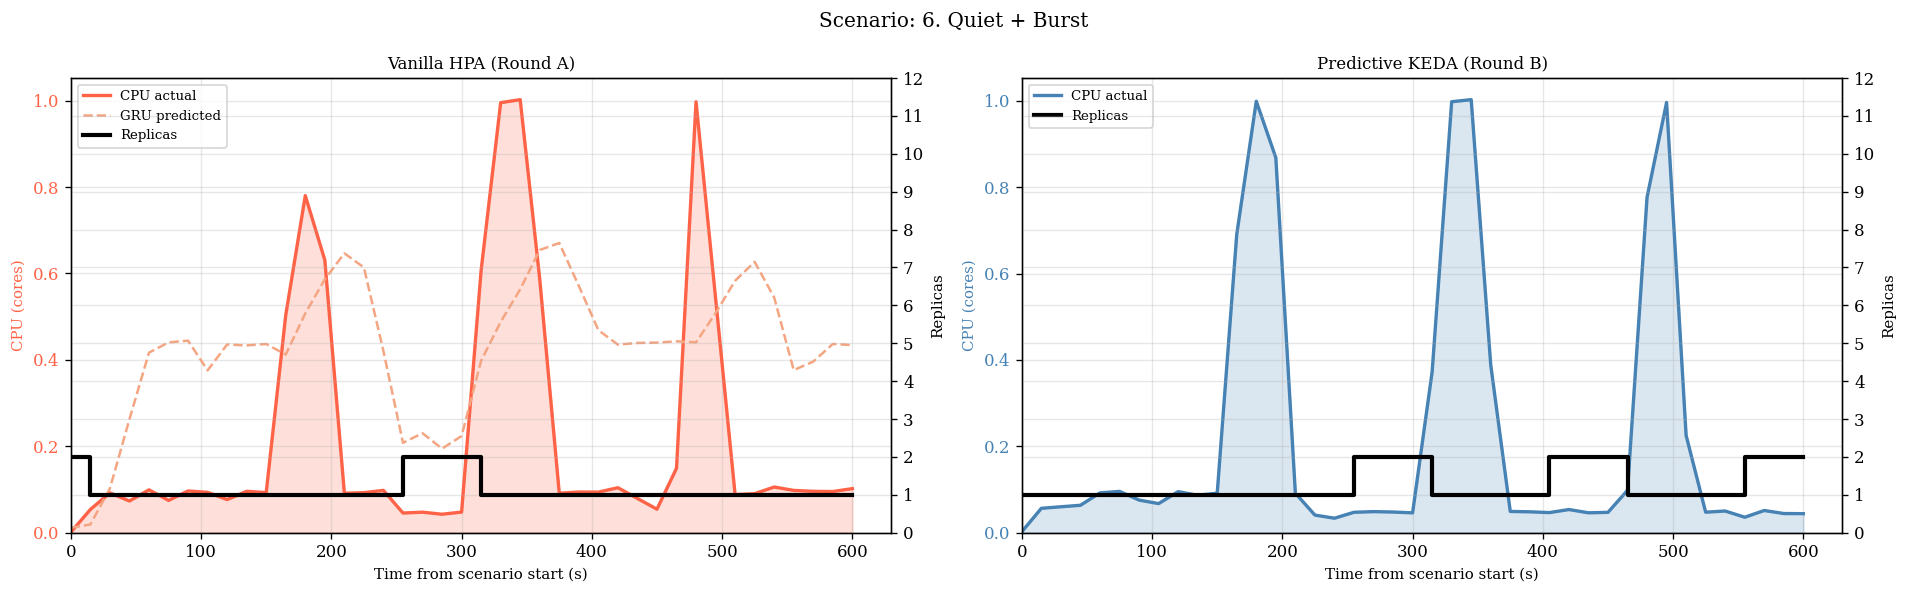

In [15]:
for scenario in ['4. Multi Spike', '6. Quiet + Burst']:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Scenario: {scenario}', fontsize=12)

    for ax, (round_key, label, color) in zip(axes, ROUNDS):
        data = fetch_scenario(round_key, scenario)
        ax2 = ax.twinx()

        if not data['cpu'].empty:
            ax.fill_between(data['cpu']['sec'], data['cpu']['value'],
                            alpha=0.2, color=color)
            ax.plot(data['cpu']['sec'], data['cpu']['value'],
                    color=color, linewidth=2, label='CPU actual')

        if round_key == 'round_a' and not data['pred'].empty:
            ax.plot(data['pred']['sec'], data['pred']['value'],
                    color=COLOR_PRED, linewidth=1.5, linestyle='--', label='GRU predicted')

        if not data['replicas'].empty:
            ax2.step(data['replicas']['sec'], data['replicas']['value'],
                     color='black', linewidth=2.5, where='post', label='Replicas')

        ax.set_title(label, fontsize=10)
        ax.set_xlabel('Time from scenario start (s)')
        ax.set_ylabel('CPU (cores)', color=color)
        ax.tick_params(axis='y', labelcolor=color)
        ax.set_ylim(bottom=0)
        ax.set_xlim(left=0)
        ax2.set_ylabel('Replicas')
        ax2.set_ylim(0, 12)
        ax2.yaxis.set_major_locator(mticker.MultipleLocator(1))

        lines1, labs1 = ax.get_legend_handles_labels()
        lines2, labs2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper left')

    plt.tight_layout()
    slug = scenario.replace('. ', '_').replace(' ', '_').lower()
    plt.savefig(f'../notebooks/focus_{slug}.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 4 — Overall Summary

In [16]:
stats_a = pd.read_csv(RESULTS / 'round_a_stats.csv')
stats_b = pd.read_csv(RESULTS / 'round_b_stats.csv')
agg_a = stats_a[stats_a['Name'] == 'Aggregated'].iloc[0]
agg_b = stats_b[stats_b['Name'] == 'Aggregated'].iloc[0]

print('=== Overall Experiment Summary ===')
print(f'{"Metric":<30}  {"HPA (A)":>14}  {"KEDA (B)":>13}')
print('-' * 62)
for label, col_a, col_b, fmt in [
    ('Total Requests',        agg_a['Request Count'],         agg_b['Request Count'],         '{:.0f}'),
    ('Total Failures',        agg_a['Failure Count'],         agg_b['Failure Count'],         '{:.0f}'),
    ('Failure Rate (%)',      agg_a['Failure Count']/max(agg_a['Request Count'],1)*100,
                             agg_b['Failure Count']/max(agg_b['Request Count'],1)*100,         '{:.4f}'),
    ('Median Latency (ms)',   agg_a['Median Response Time'],  agg_b['Median Response Time'],  '{:.1f}'),
    ('Avg Latency (ms)',      agg_a['Average Response Time'], agg_b['Average Response Time'], '{:.1f}'),
    ('P95 (ms)',              agg_a['95%'],                   agg_b['95%'],                   '{:.0f}'),
    ('P99 (ms)',              agg_a['99%'],                   agg_b['99%'],                   '{:.0f}'),
    ('Max Latency (ms)',      agg_a['Max Response Time'],     agg_b['Max Response Time'],     '{:.0f}'),
    ('Avg RPS',               agg_a['Requests/s'],            agg_b['Requests/s'],            '{:.2f}'),
]:
    print(f'{label:<30}  {fmt.format(col_a):>14}  {fmt.format(col_b):>13}')

print()
print('Saved figures:')
for f in sorted(Path('../notebooks').glob('*.png')):
    print(f'  notebooks/{f.name}')

=== Overall Experiment Summary ===
Metric                                 HPA (A)       KEDA (B)
--------------------------------------------------------------
Total Requests                           36815          36935
Total Failures                               0              0
Failure Rate (%)                        0.0000         0.0000
Median Latency (ms)                      670.0          680.0
Avg Latency (ms)                         711.8          706.2
P95 (ms)                                  1800           1800
P99 (ms)                                  2400           2400
Max Latency (ms)                          4089           3738
Avg RPS                                   8.52           8.55

Saved figures:
  notebooks/average_response_time_plot.png
  notebooks/best_config_training.png
  notebooks/detailed_percentiles_plot.png
  notebooks/eda_correlation.png
  notebooks/eda_cross_correlation.png
  notebooks/eda_cross_correlation_bars.png
  notebooks/eda_log_returns_vis